In [1]:
import os
import torch
import sys
module_path = os.path.abspath(os.path.join('..', 'common'))
if module_path not in sys.path:
    sys.path.append(module_path)
from display_particles import draw_particles
from training_stage import _ModuleList
import matplotlib.pyplot as plt
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
from main import make_stage_info, make_trainer_stage, make_generic_stage_info, get_data
from pathlib import Path
dx = dy = 2

ParallelSmoother_0.proposal.kalman.prior_model.mean
Parameter containing:
tensor([ 0.2280, -0.0371], device='cuda:0', requires_grad=True)
ParallelSmoother_0.proposal.kalman.prior_model.cholesky_covariance_
Parameter containing:
tensor([[ 0.1080,  0.0000],
        [-0.0146,  0.4230]], device='cuda:0', requires_grad=True)
ParallelSmoother_0.proposal.kalman.dynamic_model.mean_fun.weight
Parameter containing:
tensor([[0.2602, 0.0184],
        [0.0998, 0.2872]], device='cuda:0', requires_grad=True)
ParallelSmoother_0.proposal.kalman.dynamic_model.mean_fun.bias
Parameter containing:
tensor([ 0.1275, -0.0374], device='cuda:0', requires_grad=True)
ParallelSmoother_0.proposal.kalman.dynamic_model.dist.cholesky_covariance_
Parameter containing:
tensor([[0.1054, 0.0000],
        [0.0000, 0.2717]], device='cuda:0', requires_grad=True)
ParallelSmoother_0.proposal.kalman.observation_model.mean_fun.weight
Parameter containing:
tensor([[0.5020, 0.0144],
        [0.4206, 0.3042]], device='cuda:0', requ

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.


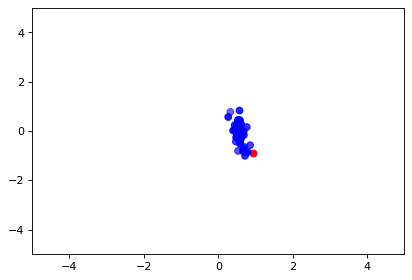

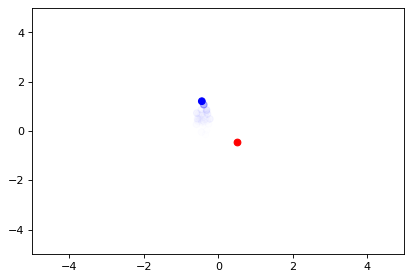

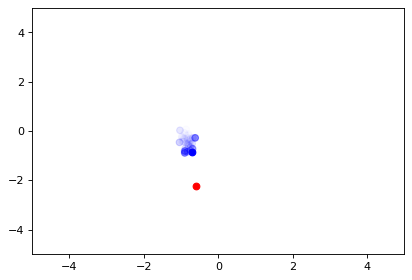

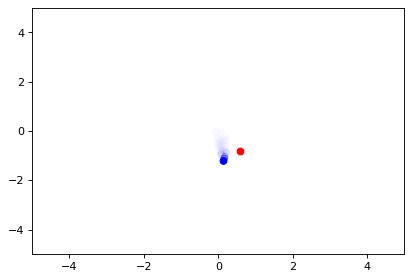

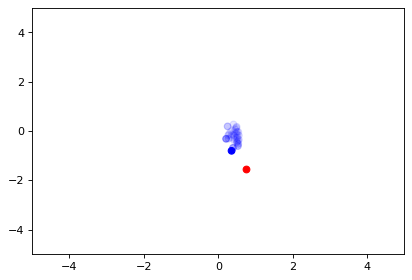

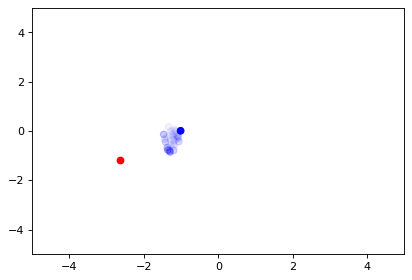

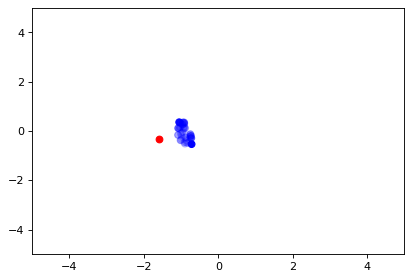

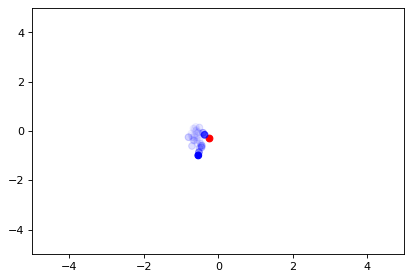

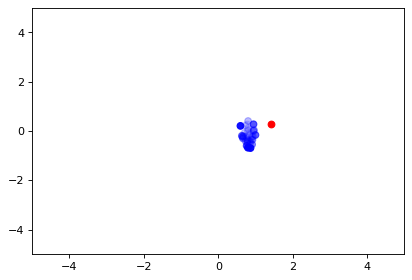

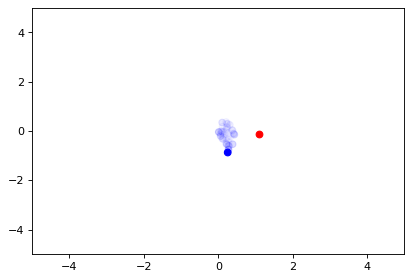

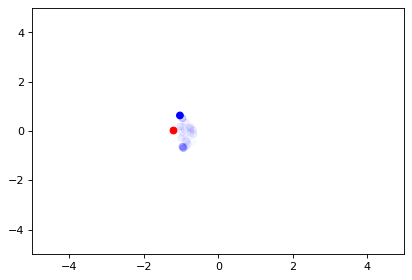

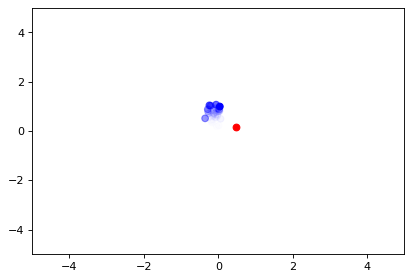

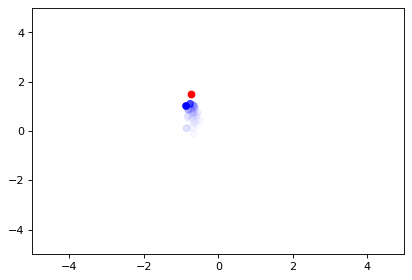

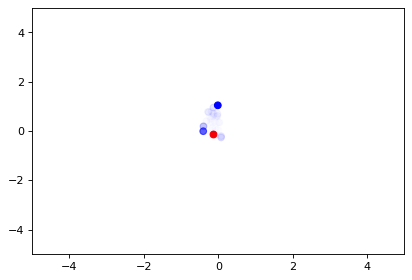

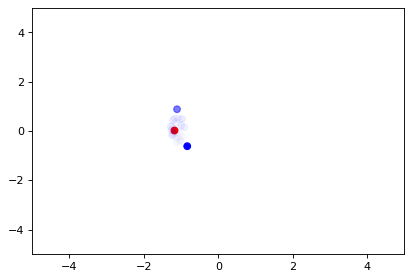

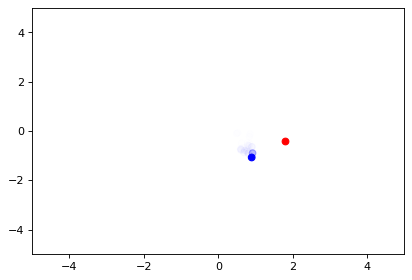

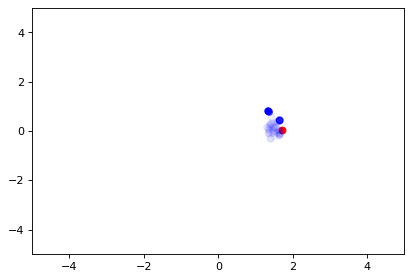

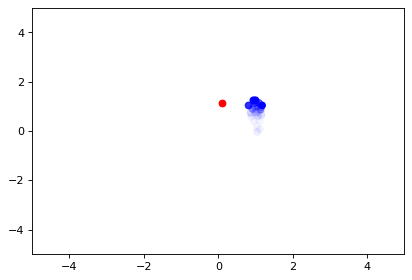

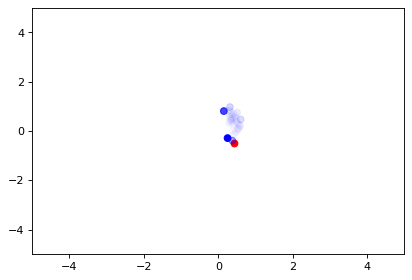

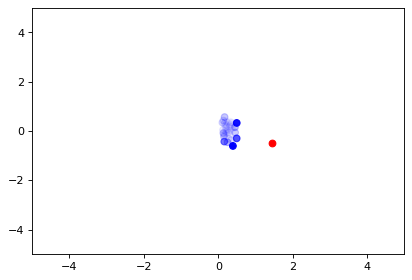

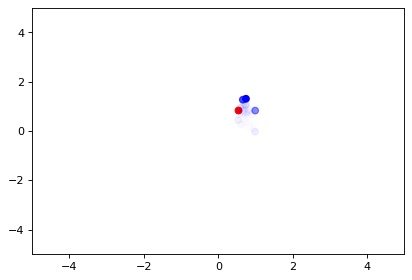

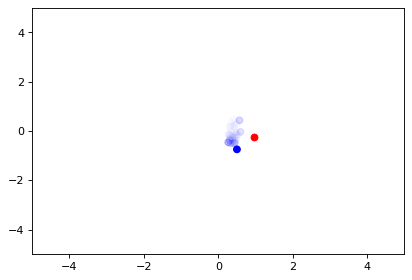

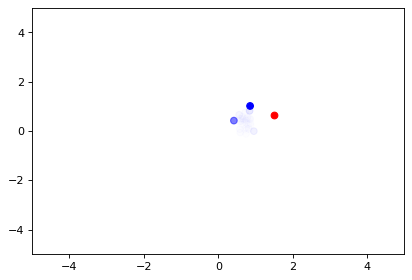

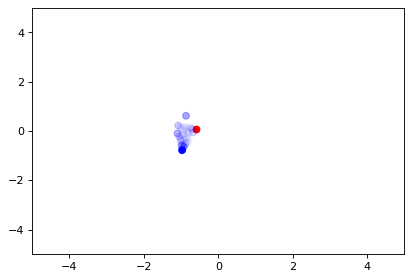

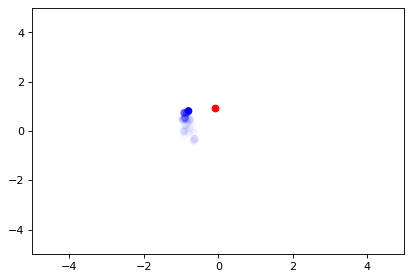

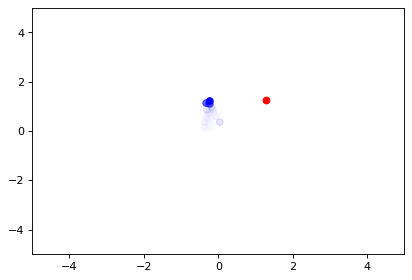

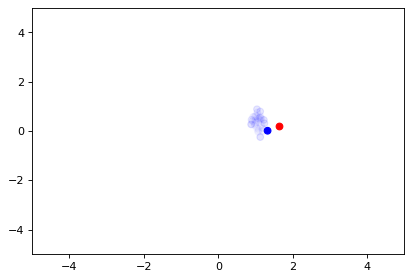

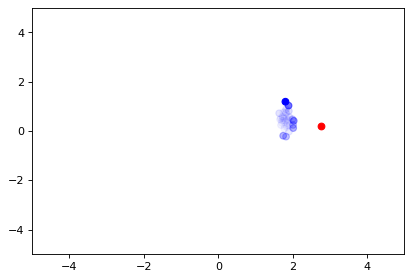

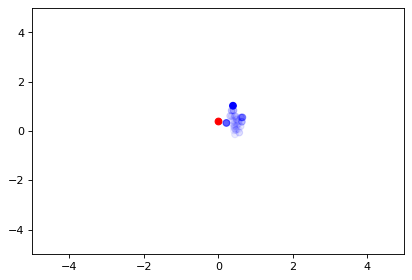

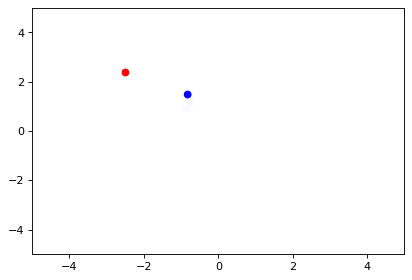

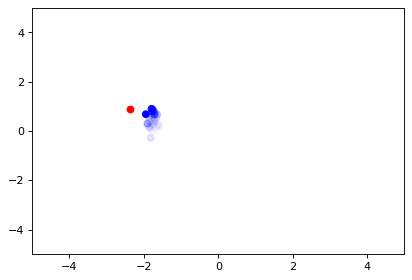

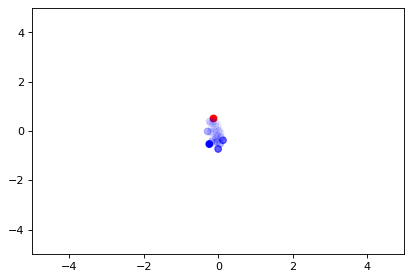

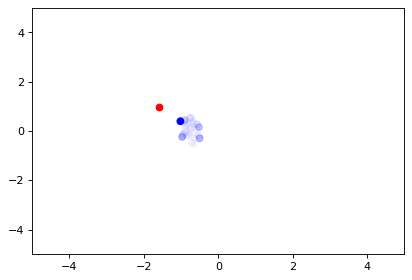

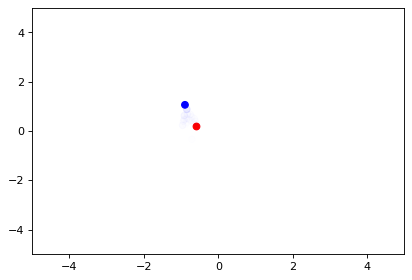

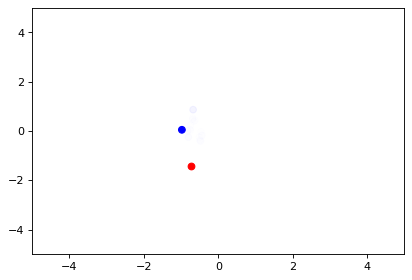

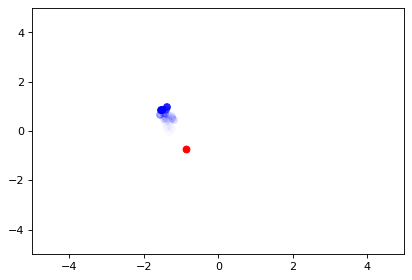

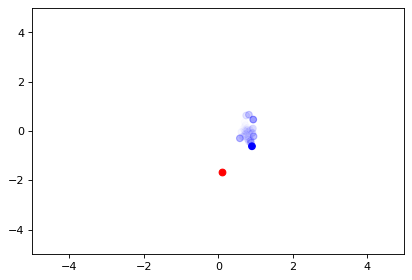

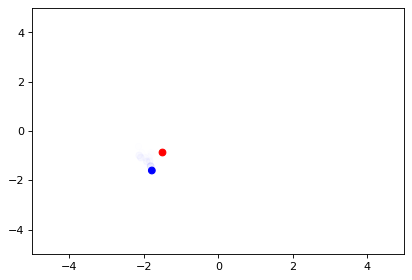

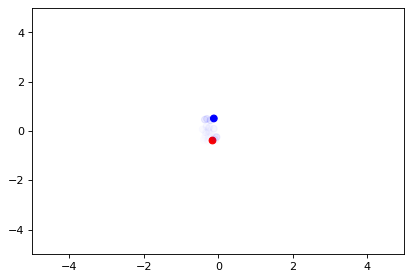

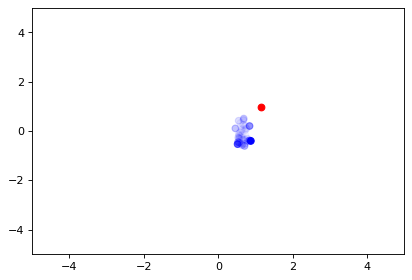

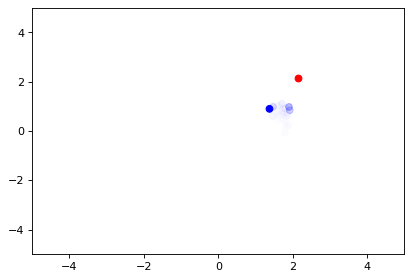

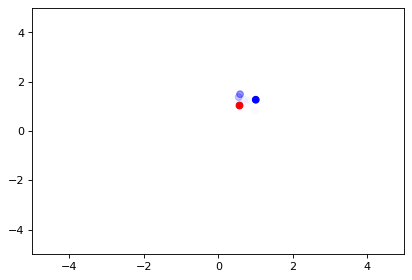

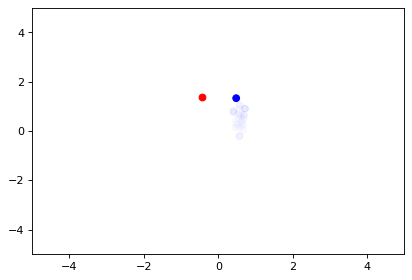

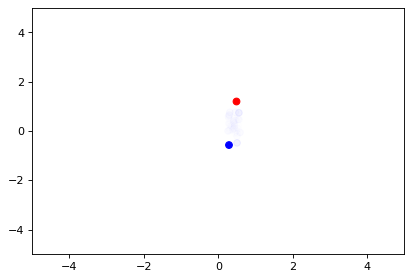

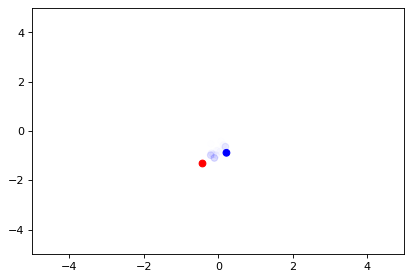

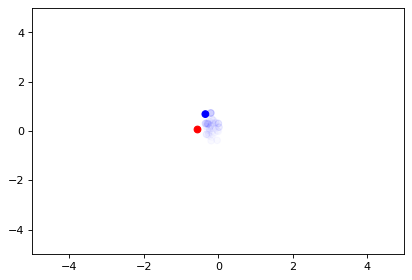

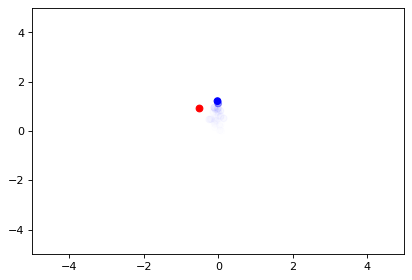

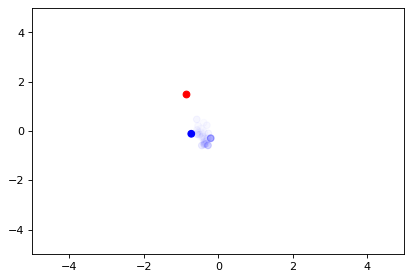

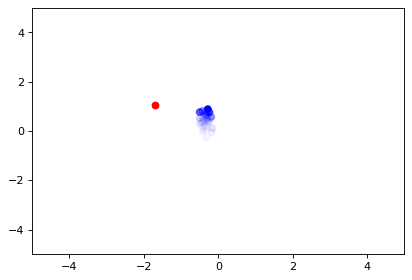

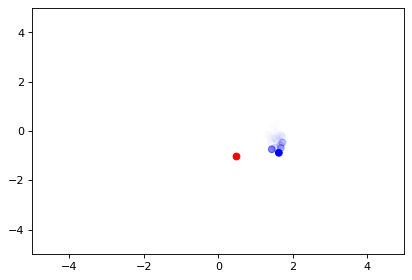

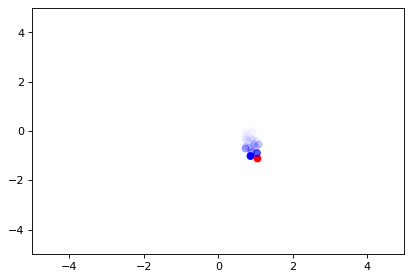

In [2]:
train_set, validation_set, test_set = get_data(Path("./data/"), dx, dy)
train_info, validation_info, test_info = make_generic_stage_info(train_set, validation_set, test_set, (50,50,50), (1,1,1), (50,50,50), {})
info = make_stage_info(train_info, validation_info, test_info, "na", "na", 1, {}, {}, 'cuda:0')
info["weights_path"] = Path("./saved_models/PVMC-2-2_stage_1_model_state.pt")
model, stage = make_trainer_stage("pvmc", dx, dy, device, train_set, validation_set, test_set)
model = _ModuleList([model])
figs = draw_particles(model, stage.run_func, info, test_set, ["ground_truth", "observation"], (0,1))
for fig in figs:
    display(fig)
    plt.close(fig)